## Importing Packages

In [18]:
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fastf1.plotting.setup_mpl()

## Loading Session Data

In [19]:
year = 2022
race = "Japanese Grand Prix"

session = fastf1.get_session(year, race, 'R')
session.load()

logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
req            INFO 	Data has been written to cache!
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control

## Load and Prepare Lap Data

In [20]:
laps = session.laps

laps = laps[[
    'Driver', 'LapNumber', 'LapTime',
    'Compound', 'TyreLife', 'Stint', 'Team'
]].dropna()

laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
laps.head()

,Driver,LapNumber,LapTime,Compound,TyreLife,Stint,Team,LapTimeSeconds
0,VER,1.0,0 days 00:02:02.046000,INTERMEDIATE,1.0,1.0,Red Bull Racing,122.046
5,VER,6.0,0 days 00:01:50.761000,WET,4.0,2.0,Red Bull Racing,110.761
6,VER,7.0,0 days 00:01:52.865000,WET,5.0,2.0,Red Bull Racing,112.865
7,VER,8.0,0 days 00:02:10.625000,INTERMEDIATE,1.0,3.0,Red Bull Racing,130.625
8,VER,9.0,0 days 00:01:45.148000,INTERMEDIATE,2.0,3.0,Red Bull Racing,105.148


## Driver Comparison on Same Compound

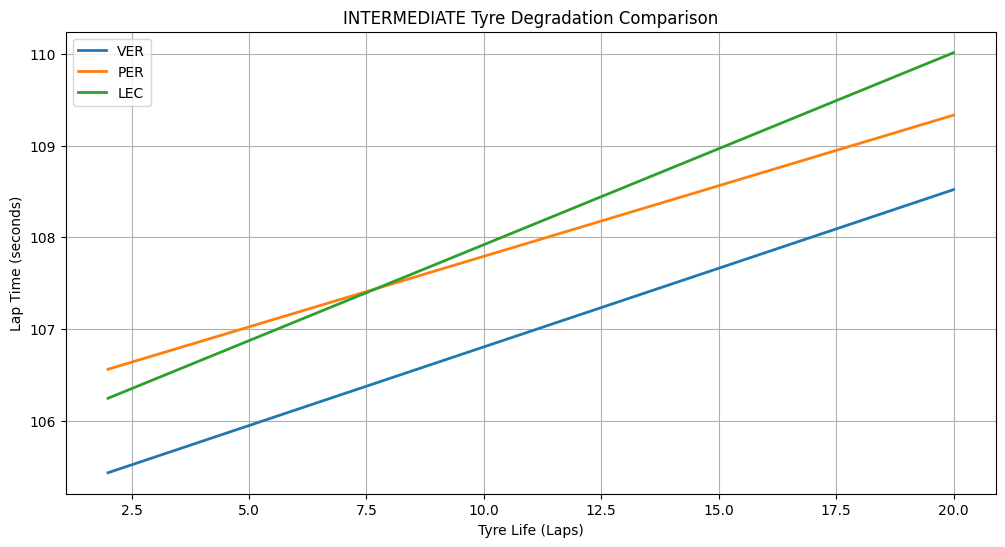

In [21]:
results = session.results

results = results.head(3)
drivers = results['Abbreviation']

# Get compounds used by each driver
driver_compounds = {
    drv: set(laps[laps['Driver'] == drv]['Compound'].unique())
    for drv in drivers
}

# Find intersection (common compounds)
common_compounds = set.intersection(*driver_compounds.values())

# Pick one (e.g., most frequent among common ones)
if common_compounds:
    compound_counts = laps[laps['Compound'].isin(common_compounds)]['Compound'].value_counts()
    compound = compound_counts.idxmax()
else:
    print("⚠️ No common compound found among top 3 drivers")
    compound = None

plt.figure(figsize=(12, 6))

for drv in drivers:
    data = laps[
        (laps['Driver'] == drv) &
        (laps['Compound'] == compound)
    ].copy()

    # 🔧 Step 1: Clean data
    data = data.dropna(subset=['TyreLife', 'LapTimeSeconds'])
    data = data[data['TyreLife'] > 1]
    data = data[data['LapTimeSeconds'] < data['LapTimeSeconds'].quantile(0.95)]

    if data.empty:
        print(f"⚠️ Skipping {drv} (no data)")
        continue

    if len(data) < 3:
        continue

    z = np.polyfit(data['TyreLife'], data['LapTimeSeconds'], 1)
    p = np.poly1d(z)

    plt.plot(
        data['TyreLife'],
        p(data['TyreLife']),
        label=drv,
        linewidth=2
    )

plt.title(f"{compound} Tyre Degradation Comparison")
plt.xlabel("Tyre Life (Laps)")
plt.ylabel("Lap Time (seconds)")
plt.legend()
plt.grid(True)

plt.show()

## Driver Comparison on Different Compound

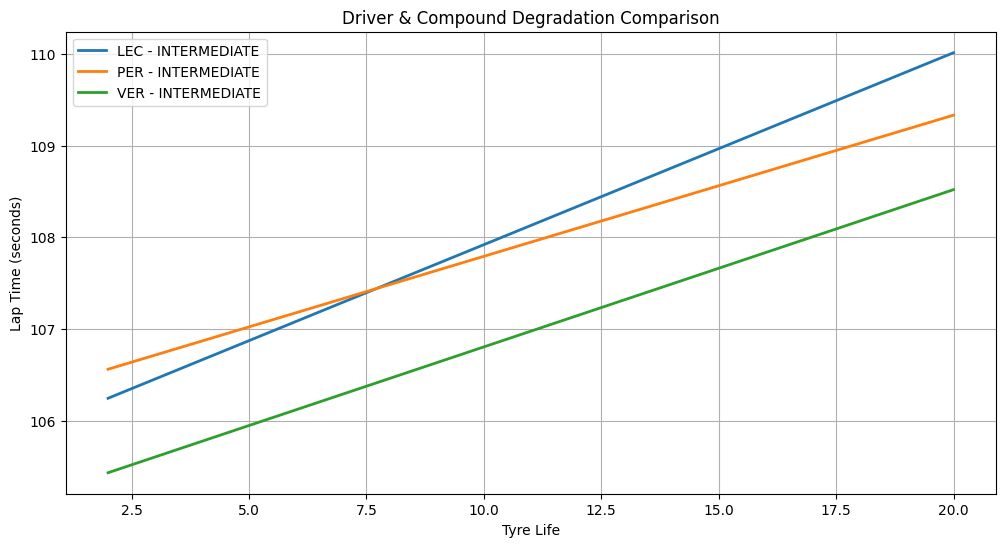

In [22]:
comparison = laps[laps['Driver'].isin(drivers)].copy()

plt.figure(figsize=(12, 6))

plotted = False

for (drv, comp), data in comparison.groupby(['Driver', 'Compound']):

    # 🔧 Step 1: Clean data
    data = data.dropna(subset=['TyreLife', 'LapTimeSeconds'])
    data = data[data['TyreLife'] > 1]
    data = data[data['LapTimeSeconds'] < data['LapTimeSeconds'].quantile(0.95)]

    if data.empty:
        continue

    data = data.sort_values('TyreLife')

    if len(data) < 3:
        continue

    # 🔧 Step 3: Use linear smoothing (IMPORTANT)
    z = np.polyfit(data['TyreLife'], data['LapTimeSeconds'], 1)
    p = np.poly1d(z)

    plt.plot(
        data['TyreLife'],
        p(data['TyreLife']),
        label=f"{drv} - {comp}",
        linewidth=2
    )

    plotted = True

# ✅ Avoid legend warning
if plotted:
    plt.legend()

plt.xlabel("Tyre Life")
plt.ylabel("Lap Time (seconds)")
plt.title("Driver & Compound Degradation Comparison")
plt.grid(True)

plt.show()